# Bonus: GraphRAG with Neo4j

Build a **Knowledge Graph** from the same PDF documents (KTZh and Maten Petroleum) and use it to answer questions that are poorly handled by standard Vector RAG.

### Architecture

```
Parsed Markdown → LLM Entity Extraction → Knowledge Graph (Neo4j) → Cypher Queries → LLM Answer
```

| Step | Technology | Description |
|------|-----------|-------------|
| 1. Entity extraction | GPT-4o-mini + neo4j-graphrag | LLM extracts entities and relationships from text |
| 2. Graph storage | Neo4j | Knowledge graph with nodes and edges |
| 3. Vector index | Neo4j Vector Index | Node embeddings for semantic search |
| 4. Retrieval | VectorCypherRetriever | Vector search + graph traversal |
| 5. Generation | GPT-4o-mini | Answer based on graph context |

In [31]:
import os
import sys
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# Add project root to path for src imports
sys.path.insert(0, os.path.abspath(".."))

load_dotenv(os.path.join("..", ".env"))

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
NEO4J_URI = os.getenv("NEO4J_URI", "neo4j://localhost:7687")
NEO4J_USER = os.getenv("NEO4J_USER", "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD", "password123")

os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

print(f"Neo4j URI: {NEO4J_URI}")
print(f"OpenAI API key: {'set' if OPENAI_API_KEY else 'MISSING!'}")

Neo4j URI: neo4j://localhost:7687
OpenAI API key: set


In [32]:
import logging
logging.getLogger("neo4j").setLevel(logging.ERROR)

from neo4j import GraphDatabase

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
driver.verify_connectivity()
print("Neo4j connected!")

Neo4j connected!


---
## 1. Data Preparation

Load parsed markdown files from both reports and split into fragments for entity extraction.

In [33]:
# Load parsed documents
parsed_dir = os.path.join("..", "data", "parsed")

with open(os.path.join(parsed_dir, "ktj.md"), "r", encoding="utf-8") as f:
    ktj_text = f.read()

with open(os.path.join(parsed_dir, "matnp_2024_rus.md"), "r", encoding="utf-8") as f:
    matnp_text = f.read()

print(f"KTZh: {len(ktj_text)} chars")
print(f"Maten Petroleum: {len(matnp_text)} chars")

KTZh: 70944 chars
Maten Petroleum: 49356 chars


In [34]:
def split_into_sections(text: str, max_chars: int = 3000) -> list[str]:
    """Split text into sections by markdown headers, limiting size."""
    # Split by top-level headers
    sections = re.split(r'(?=\n# )', text)
    
    result = []
    for section in sections:
        section = section.strip()
        if not section or len(section) < 100:
            continue
        # If section is too large, split further by sub-headers
        if len(section) > max_chars:
            subsections = re.split(r'(?=\n## )', section)
            for sub in subsections:
                sub = sub.strip()
                if len(sub) > 100:
                    result.append(sub[:max_chars])
        else:
            result.append(section)
    return result

ktj_sections = split_into_sections(ktj_text)
matnp_sections = split_into_sections(matnp_text)

# Take the most informative sections (not all 300+ pages — too expensive for LLM)
# Focus on key sections: management overview, strategy, financials, ESG
ktj_fragments = ktj_sections[:30]  # First 30 sections (overview, strategy, financials)
matnp_fragments = matnp_sections[:20]  # All main sections of Maten

all_fragments = []
for frag in ktj_fragments:
    all_fragments.append(("ktj.pdf", frag))
for frag in matnp_fragments:
    all_fragments.append(("matnp_2024_rus.pdf", frag))

print(f"Prepared {len(all_fragments)} fragments")
print(f"  KTZh: {len(ktj_fragments)} fragments")
print(f"  Maten: {len(matnp_fragments)} fragments")
for i, (src, frag) in enumerate(all_fragments[:5]):
    print(f"  [{src}] Fragment {i+1}: {len(frag)} chars — {frag[:80]}...")

Prepared 50 fragments
  KTZh: 30 fragments
  Maten: 20 fragments
  [ktj.pdf] Fragment 1: 341 chars — Одобрен                                Утвержден
решением Правления    решением ...
  [ktj.pdf] Fragment 2: 3000 chars — # Изменения

| Ключевые показатели                                             |...
  [ktj.pdf] Fragment 3: 3000 chars — # Условные обозначения, используемые в Отчете

Для удобства использования в Отче...
  [ktj.pdf] Fragment 4: 189 chars — # КОНТАКТНАЯ ИНФОРМАЦИЯ

85, 91, 115, 134, 157, 170, 207, 211, 225, 229, 230, 26...
  [ktj.pdf] Fragment 5: 2708 chars — # Уважаемые акционер, партнеры, инвесторы и читатели Годового отчета!

От имени ...


---
## 2. Build Knowledge Graph via SimpleKGPipeline

Using **neo4j-graphrag-python** — the official Neo4j package.

- **LLMEntityRelationExtractor** — GPT-4o-mini extracts entities and relationships
- **Schema** — node and relationship types for a structured graph
- **Entity Resolution** — merges duplicates ("KTZh" and "NK KTZh")

In [35]:
from neo4j_graphrag.experimental.pipeline.kg_builder import SimpleKGPipeline
from neo4j_graphrag.embeddings.openai import OpenAIEmbeddings
from neo4j_graphrag.llm import OpenAILLM

# --- Define node types (entities) adapted for annual reports ---
node_types = [
    "Organization",    # Companies: KTZh, Maten Petroleum, Kozhan, subsidiaries
    "Person",          # Executives, board members
    "Project",         # Infrastructure projects: Dostyk-Moiynty, etc.
    "Location",        # Cities, oilfields, stations
    "Standard",        # ISO, GRI, TCFD standards
    "Metric",          # Financial indicators: revenue, EBITDA
    "Strategy",        # Development strategies, plans
    "Product",         # Products, services
    "Event",           # Events: investment rounds, partnerships, contracts
]

# Relationship types
relationship_types = [
    "SUBSIDIARY_OF",        # subsidiary company
    "LOCATED_IN",           # located in
    "MANAGES",              # manages / leads
    "WORKS_AT",             # works at
    "IMPLEMENTS",           # implements standard/strategy
    "DEVELOPS",             # develops project
    "HAS_METRIC",           # has metric/indicator
    "OPERATES_IN",          # operates in (oilfield)
    "PARTNER_OF",           # partner of
    "COMPETES_WITH",        # competes with
    "PART_OF",              # part of
    "PROVIDES_SERVICE",     # provides service
    "OWNS",                 # owns
    "TARGETS",              # targets (goal)
]

# Allowed patterns (from -> relationship -> to)
patterns = [
    ("Organization", "SUBSIDIARY_OF", "Organization"),
    ("Organization", "LOCATED_IN", "Location"),
    ("Organization", "IMPLEMENTS", "Standard"),
    ("Organization", "DEVELOPS", "Project"),
    ("Organization", "HAS_METRIC", "Metric"),
    ("Organization", "OPERATES_IN", "Location"),
    ("Organization", "PARTNER_OF", "Organization"),
    ("Organization", "COMPETES_WITH", "Organization"),
    ("Organization", "OWNS", "Organization"),
    ("Organization", "PROVIDES_SERVICE", "Product"),
    ("Organization", "TARGETS", "Strategy"),
    ("Person", "MANAGES", "Organization"),
    ("Person", "WORKS_AT", "Organization"),
    ("Project", "LOCATED_IN", "Location"),
    ("Project", "PART_OF", "Strategy"),
    ("Strategy", "TARGETS", "Metric"),
    ("Metric", "PART_OF", "Organization"),
]

print(f"Node types: {len(node_types)}")
print(f"Relationship types: {len(relationship_types)}")
print(f"Patterns: {len(patterns)}")

Node types: 9
Relationship types: 14
Patterns: 17


In [36]:
# --- Initialize LLM and Embeddings ---

llm = OpenAILLM(
    model_name="gpt-4o-mini",
    model_params={
        "temperature": 0,
        "max_tokens": 3000,
        "response_format": {"type": "json_object"},
    },
)

embedder = OpenAIEmbeddings(model="text-embedding-3-small")

print("LLM: GPT-4o-mini")
print("Embedder: text-embedding-3-small")

LLM: GPT-4o-mini
Embedder: text-embedding-3-small


In [37]:
# --- Create SimpleKGPipeline ---

kg_builder = SimpleKGPipeline(
    llm=llm,
    driver=driver,
    embedder=embedder,
    schema={
        "node_types": node_types,
        "relationship_types": relationship_types,
        "patterns": patterns,
    },
    from_pdf=False,
    on_error="IGNORE",
    perform_entity_resolution=True,
)

print("SimpleKGPipeline created!")
print("  - Entity Resolution: enabled")
print("  - on_error: IGNORE")

SimpleKGPipeline created!
  - Entity Resolution: enabled
  - on_error: IGNORE


In [38]:
# --- Clear database (for re-runs) ---

with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")
    print("Neo4j database cleared.")

Neo4j database cleared.


In [39]:
# --- Build Knowledge Graph ---
import logging
logging.getLogger("neo4j").setLevel(logging.ERROR)

async def build_knowledge_graph(fragments: list[tuple[str, str]]):
    """Process each text fragment through the KG pipeline."""
    success = 0
    errors = 0
    for i, (source, text) in enumerate(fragments):
        try:
            result = await kg_builder.run_async(text=text)
            success += 1
        except Exception as e:
            print(f"  Fragment {i+1} error: {str(e)[:100]}")
            errors += 1
        if (i + 1) % 10 == 0 or i == len(fragments) - 1:
            print(f"  Progress: {i+1}/{len(fragments)} [{source}] (success={success}, errors={errors})")
    print(f"\nDone! Success: {success}, Errors: {errors}")

await build_knowledge_graph(all_fragments)

  Progress: 10/50 [ktj.pdf] (success=10, errors=0)
  Progress: 20/50 [ktj.pdf] (success=20, errors=0)
  Progress: 30/50 [ktj.pdf] (success=30, errors=0)
  Progress: 40/50 [matnp_2024_rus.pdf] (success=40, errors=0)
  Progress: 50/50 [matnp_2024_rus.pdf] (success=50, errors=0)

Done! Success: 50, Errors: 0


---
## 3. Exploring the Knowledge Graph

Run Cypher queries against Neo4j to see what the LLM extracted from the reports.

In [40]:
def run_cypher(query: str, params: dict = None) -> list:
    """Execute a Cypher query and return results."""
    with driver.session() as session:
        result = session.run(query, parameters=params or {})
        return [dict(record) for record in result]

# --- Graph statistics ---
node_count = run_cypher("MATCH (n) RETURN count(n) AS count")[0]["count"]
rel_count = run_cypher("MATCH ()-[r]->() RETURN count(r) AS count")[0]["count"]

print(f"Total nodes: {node_count}")
print(f"Total relationships: {rel_count}")

# Nodes by type
print("\nNodes by type:")
label_stats = run_cypher("""
    MATCH (n) 
    UNWIND labels(n) AS label 
    RETURN label, count(*) AS count 
    ORDER BY count DESC
""")
for row in label_stats:
    print(f"  {row['label']}: {row['count']}")

Total nodes: 394
Total relationships: 564

Nodes by type:
  __KGBuilder__: 394
  __Entity__: 294
  Organization: 114
  Location: 59
  Document: 50
  Chunk: 50
  Metric: 43
  Person: 25
  Project: 25
  Event: 13
  Product: 8
  Standard: 6
  Strategy: 1


In [41]:
# --- All relationships in the graph ---

print("Relationships in knowledge graph:")
print("=" * 80)

relationships = run_cypher("""
    MATCH (a)-[r]->(b)
    RETURN labels(a)[0] AS from_type, 
           a.name AS from_name,
           type(r) AS relationship,
           labels(b)[0] AS to_type,
           b.name AS to_name
    ORDER BY from_name
    LIMIT 50
""")

for row in relationships:
    print(f"  ({row['from_type']}) {row['from_name']}"
          f" --[{row['relationship']}]--> "
          f"({row['to_type']}) {row['to_name']}")

Relationships in knowledge graph:
  (__KGBuilder__) "Норт Каспиан Оперейтинг Компани Б.В." --[FROM_CHUNK]--> (__KGBuilder__) None
  (__KGBuilder__) 2023 год --[FROM_CHUNK]--> (__KGBuilder__) None
  (__KGBuilder__) 8-я Международная выставка «Шёлковый путь» --[FROM_CHUNK]--> (__KGBuilder__) None
  (__KGBuilder__) AI Development --[FROM_CHUNK]--> (__KGBuilder__) None
  (__KGBuilder__) BG Group --[FROM_CHUNK]--> (__KGBuilder__) None
  (__KGBuilder__) Bahnoperator Austria GmbH --[FROM_CHUNK]--> (__KGBuilder__) None
  (__KGBuilder__) CNPC --[FROM_CHUNK]--> (__KGBuilder__) None
  (__KGBuilder__) CRRC Corporation Limited --[FROM_CHUNK]--> (__KGBuilder__) None
  (__KGBuilder__) CRRC Corporation Limited --[LOCATED_IN]--> (__KGBuilder__) Китай
  (__KGBuilder__) CRRC Corporation Limited --[LOCATED_IN]--> (__KGBuilder__) Астана
  (__KGBuilder__) CRRC Corporation Limited --[FROM_CHUNK]--> (__KGBuilder__) None
  (__KGBuilder__) Chevron --[FROM_CHUNK]--> (__KGBuilder__) None
  (__KGBuilder__) China R

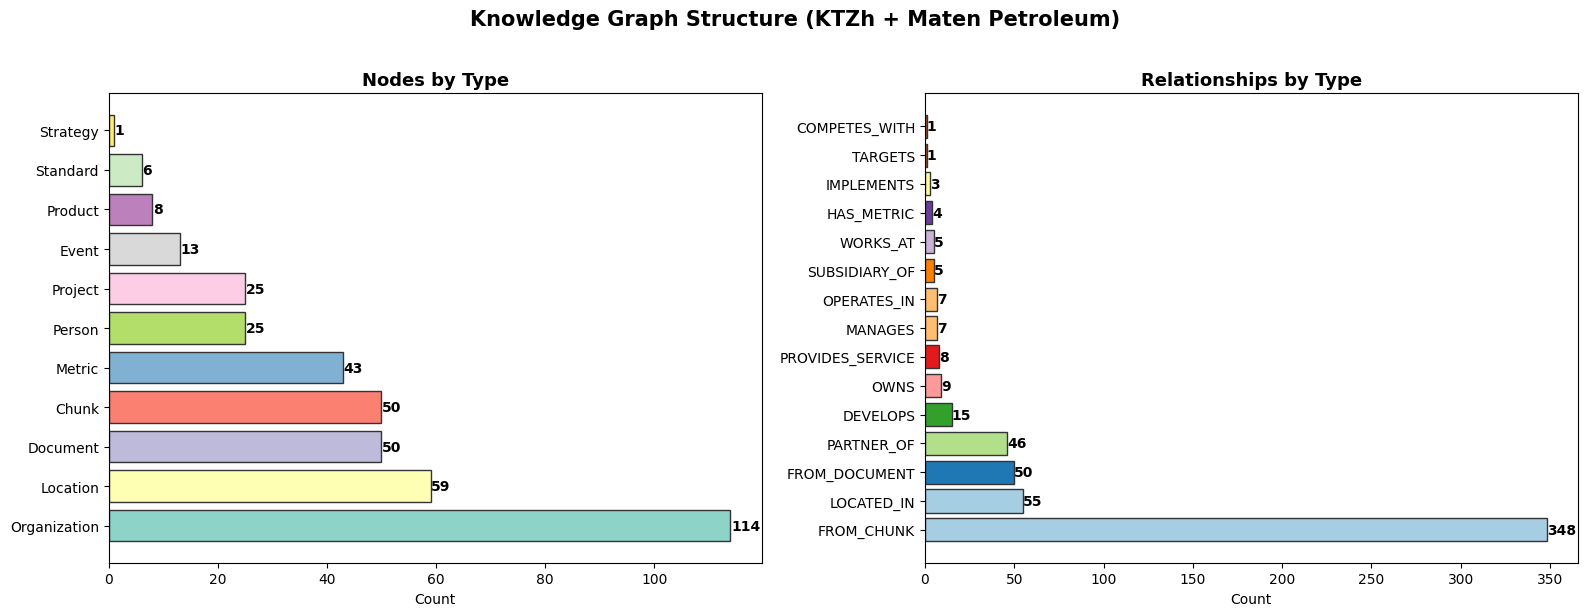

In [42]:
# --- Graph structure visualization ---

rel_type_stats = run_cypher("""
    MATCH ()-[r]->()
    RETURN type(r) AS rel_type, count(*) AS count
    ORDER BY count DESC
""")

# Filter out internal label types
label_stats_filtered = [r for r in label_stats if r["label"] not in ("__Entity__", "__KGBuilder__")]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Nodes by type
if label_stats_filtered:
    labels_plot = [r["label"] for r in label_stats_filtered]
    counts_plot = [r["count"] for r in label_stats_filtered]
    colors = plt.cm.Set3(np.linspace(0, 1, len(labels_plot)))
    axes[0].barh(labels_plot, counts_plot, color=colors, edgecolor="#333")
    axes[0].set_title("Nodes by Type", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Count")
    for i, (label, count) in enumerate(zip(labels_plot, counts_plot)):
        axes[0].text(count + 0.1, i, str(count), va="center", fontweight="bold")

# Relationships by type
if rel_type_stats:
    rel_labels = [r["rel_type"] for r in rel_type_stats]
    rel_counts = [r["count"] for r in rel_type_stats]
    colors2 = plt.cm.Paired(np.linspace(0, 1, len(rel_labels)))
    axes[1].barh(rel_labels, rel_counts, color=colors2, edgecolor="#333")
    axes[1].set_title("Relationships by Type", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Count")
    for i, (label, count) in enumerate(zip(rel_labels, rel_counts)):
        axes[1].text(count + 0.05, i, str(count), va="center", fontweight="bold")

plt.suptitle("Knowledge Graph Structure (KTZh + Maten Petroleum)",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Example Cypher Queries

Multi-hop queries — what distinguishes GraphRAG from standard Vector RAG.

In [43]:
print("=" * 80)
print("CYPHER QUERIES TO KNOWLEDGE GRAPH")
print("=" * 80)

# Query 1: Infrastructure projects related to KTZh
print("\n1. KTZh projects:")
r1 = run_cypher("""
    MATCH (org)-[:DEVELOPS]->(proj:Project)
    WHERE org.name CONTAINS 'КТЖ' OR org.name CONTAINS 'Қазақстан'
    RETURN org.name AS company, collect(proj.name) AS projects
""")
for row in r1:
    print(f"   {row['company']} -> Projects: {row['projects']}")

# Query 2: Subsidiaries
print("\n2. Subsidiaries:")
r2 = run_cypher("""
    MATCH (child)-[:SUBSIDIARY_OF|PART_OF]->(parent)
    RETURN parent.name AS parent, collect(child.name) AS subsidiaries
""")
for row in r2:
    print(f"   {row['parent']} -> Subsidiaries: {row['subsidiaries']}")

# Query 3: ISO standards
print("\n3. Implemented standards:")
r3 = run_cypher("""
    MATCH (org)-[:IMPLEMENTS]->(std:Standard)
    RETURN org.name AS company, collect(std.name) AS standards
""")
for row in r3:
    print(f"   {row['company']} -> {row['standards']}")

# Query 4: Organizations and their locations
print("\n4. Company locations:")
r4 = run_cypher("""
    MATCH (org:Organization)-[:LOCATED_IN|OPERATES_IN]->(loc:Location)
    RETURN org.name AS company, collect(DISTINCT loc.name) AS locations
""")
for row in r4:
    print(f"   {row['company']} -> {row['locations']}")

# Query 5: Multi-hop — companies connected via shared locations
print("\n5. Multi-hop: Companies connected via shared locations:")
r5 = run_cypher("""
    MATCH (org1:Organization)-[:LOCATED_IN]->(loc:Location)<-[:LOCATED_IN]-(org2:Organization)
    WHERE org1.name <> org2.name
    RETURN org1.name AS company1, loc.name AS location, org2.name AS company2
    LIMIT 10
""")
for row in r5:
    print(f"   {row['company1']} <--[{row['location']}]--> {row['company2']}")

CYPHER QUERIES TO KNOWLEDGE GRAPH

1. KTZh projects:

2. Subsidiaries:
   акционерного общества -> Subsidiaries: ['Национальная компания «Қазақстан темір жолы»']
   АО «НК КТЖ» -> Subsidiaries: ['ЗАО «НК КТЖ»']
   ЗАО «НК КТЖ» -> Subsidiaries: ['АОКТЖ - Грузовые перевозки']
   АОКТЖ - Грузовые перевозки -> Subsidiaries: ['ТОО «КТЖ-Грузовые перевозки»']
   Moody's Investors Service -> Subsidiaries: ['АО «НК «ҚТЖ»']

3. Implemented standards:
   АО «НК «ҚТЖ» -> ['GRI', 'TCFD', 'SASB']

4. Company locations:
   АО «Матен Петролеум» -> ['Казахстан']
   АО «МАТЕН ПЕТРОЛЕУМ» -> ['Казахстан']
   АО «НК «ҚТЖ» -> ['Казахстан', 'Китай', 'Россия', 'Узбекистан', 'Кыргызстан', 'Туркменистан', 'страна', 'Китайская Народная Республика', 'Российская Федерация', 'Исламская Республика Иран', 'Центрально-Азиатский и Кавказский регион', 'Турецкая Республика', 'г. Урумчи', 'г. Москва', 'г. Тегеран', 'г. Ташкент', 'г. Баку', 'г. Стамбул', 'Астана', 'Селятино']
   АО НК ҚТЖ -> ['Казахстан']
   KTZ Express ->

In [44]:
# --- Assignment-specific queries ---

print("\n" + "=" * 80)
print("ASSIGNMENT QUERIES")
print("=" * 80)

# "What infrastructure projects are related to the Dostyk-Moiynty route?"
print("\n1. Projects related to Dostyk-Moiynty:")
r_dm = run_cypher("""
    MATCH (n)
    WHERE n.name CONTAINS 'Достык' OR n.name CONTAINS 'Мойынты'
    OPTIONAL MATCH (n)-[r]-(connected)
    RETURN n.name AS entity, labels(n) AS types,
           collect(type(r) + ' -> ' + coalesce(connected.name, '?')) AS connections
""")
for row in r_dm:
    print(f"   {row['entity']} ({row['types']}): {row['connections']}")

# "What companies are mentioned in both reports?"
print("\n2. All organizations in the graph:")
r_orgs = run_cypher("""
    MATCH (org:Organization)
    RETURN org.name AS name
    ORDER BY org.name
""")
for row in r_orgs:
    print(f"   - {row['name']}")

# ESG and environmental projects of KTZh
print("\n3. ESG/ecology connection with KTZh:")
r_esg = run_cypher("""
    MATCH (n)
    WHERE n.name CONTAINS 'ESG' OR n.name CONTAINS 'экологи' OR n.name CONTAINS 'ISO'
    OPTIONAL MATCH (n)-[r]-(connected)
    RETURN n.name AS entity, labels(n) AS types,
           collect(type(r) + ' -> ' + coalesce(connected.name, '?')) AS connections
""")
for row in r_esg:
    print(f"   {row['entity']} ({row['types']}): {row['connections']}")


ASSIGNMENT QUERIES

1. Projects related to Dostyk-Moiynty:

2. All organizations in the graph:
   - "Норт Каспиан Оперейтинг Компани Б.В."
   - BG Group
   - Bahnoperator Austria GmbH
   - CNPC
   - CRRC Corporation Limited
   - Chevron
   - China Railway Container Transport
   - Eni
   - ExxonMobil
   - G-trans Service
   - GRI
   - Global DTC
   - Global DTC Pte Ltd
   - Inpex
   - Jiangsu International Rail Freight Express
   - Jiangsu SOHO Holdings Group
   - KPMC Ltd
   - KTZ Express
   - Maqsut Narikbayev University
   - Midia International SA
   - Moody's Investors Service
   - Moody’s
   - National Logistics Corporation (NLC)
   - PSA
   - PricewaterhouseCoopers (PwC)
   - S&P Global
   - SINO-SCIENCE NETHERLANDS ENERGY CROUP B.V
   - Shell
   - Sozak Oil and Gas
   - Tech Corp
   - Total
   - Vitol Central Asia S.A.
   - Xi'an Free Trade Port
   - Xi'an Free Trade Port Construction and Operation Co. Ltd.
   - Xian Free Trade Port Construction and Operation Co.,Ltd
   - Yuxino

---
## 5. GraphRAG Retrieval — VectorCypherRetriever + LLM

Assemble the full RAG pipeline:
1. **VectorCypherRetriever** — finds a node via vector search, then traverses the graph
2. **GraphRAG** — generates an answer based on graph context

In [45]:
# --- Create vector index ---

INDEX_NAME = "entity_embeddings"

existing = run_cypher("SHOW VECTOR INDEXES")
index_names = [idx.get("name", "") for idx in existing]

if INDEX_NAME not in index_names:
    try:
        run_cypher(f"""
            CREATE VECTOR INDEX {INDEX_NAME} IF NOT EXISTS
            FOR (n:__Entity__)
            ON (n.embedding)
            OPTIONS {{
                indexConfig: {{
                    `vector.dimensions`: 1536,
                    `vector.similarity_function`: 'cosine'
                }}
            }}
        """)
        print(f"Vector index '{INDEX_NAME}' created.")
    except Exception as e:
        print(f"Index: {e}")
else:
    print(f"Index '{INDEX_NAME}' already exists.")

print("\nVector indexes:")
for idx in run_cypher("SHOW VECTOR INDEXES"):
    print(f"  - {idx.get('name', '?')}: {idx.get('state', '?')}")

Index 'entity_embeddings' already exists.

Vector indexes:
  - entity_embeddings: ONLINE


In [46]:
from neo4j_graphrag.retrievers import VectorCypherRetriever
from neo4j_graphrag.generation import GraphRAG

# Retrieval query: after vector search, traverse graph (1-2 hops)
retrieval_query = """
OPTIONAL MATCH (node)-[r]->(neighbor)
WITH node, collect(
    node.name + ' ' + type(r) + ' ' + coalesce(neighbor.name, '')
) AS outgoing_relations
OPTIONAL MATCH (other)-[r2]->(node)
WITH node, outgoing_relations, collect(
    coalesce(other.name, '') + ' ' + type(r2) + ' ' + node.name
) AS incoming_relations
RETURN 
    node.name AS entity_name,
    labels(node) AS entity_types,
    outgoing_relations,
    incoming_relations
"""

retriever = VectorCypherRetriever(
    driver=driver,
    index_name=INDEX_NAME,
    retrieval_query=retrieval_query,
    embedder=embedder,
)

print("VectorCypherRetriever created!")
print("  Strategy: Vector Search -> Graph Traversal (1-2 hops)")

VectorCypherRetriever created!
  Strategy: Vector Search -> Graph Traversal (1-2 hops)


In [47]:
# --- Test the retriever ---

test_query = "Какие инфраструктурные проекты реализует КТЖ?"
print(f"Query: {test_query}")
print("=" * 60)

retriever_results = retriever.search(query_text=test_query, top_k=3)

for i, item in enumerate(retriever_results.items):
    print(f"\nResult {i+1}:")
    print(f"  Content: {item.content[:300]}")
    if item.metadata:
        print(f"  Metadata: {json.dumps(item.metadata, ensure_ascii=False, indent=2)[:300]}")

Query: Какие инфраструктурные проекты реализует КТЖ?


In [48]:
# --- Full GraphRAG Pipeline ---

answer_llm = OpenAILLM(
    model_name="gpt-4o-mini",
    model_params={"temperature": 0},
)

rag = GraphRAG(
    retriever=retriever,
    llm=answer_llm,
)

print("GraphRAG pipeline ready!")

GraphRAG pipeline ready!


In [49]:
# --- Test questions for GraphRAG ---

graph_questions = [
    "Какие инфраструктурные проекты связаны с направлением Достык – Мойынты?",
    "Какие компании упоминаются в обоих отчётах?",
    "Покажите связь между ESG-рейтингом КТЖ и конкретными экологическими проектами.",
    "Какие дочерние компании есть у Матен Петролеум и где они расположены?",
    "Какие стандарты ISO внедрены в КТЖ?",
    "Кто руководит КТЖ и какие стратегические цели ставит компания?",
    "Какие месторождения принадлежат Матен Петролеум?",
]

graph_answers = []
print("GraphRAG — Answers:")
print("=" * 80)

for q in graph_questions:
    print(f"\nQUESTION: {q}")
    print("-" * 60)
    try:
        response = rag.search(query_text=q, retriever_config={"top_k": 5})
        answer = response.answer
    except Exception as e:
        answer = f"Error: {e}"
    graph_answers.append({"question": q, "answer": answer})
    print(f"ANSWER: {answer}")

GraphRAG — Answers:

QUESTION: Какие инфраструктурные проекты связаны с направлением Достык – Мойынты?
------------------------------------------------------------
ANSWER: На направлении Достык – Мойынты реализуются несколько инфраструктурных проектов, включая строительство и модернизацию железнодорожных путей, развитие логистических центров и терминалов, а также улучшение транспортной инфраструктуры в прилегающих районах. Эти проекты направлены на повышение пропускной способности и улучшение транспортной доступности региона.

QUESTION: Какие компании упоминаются в обоих отчётах?
------------------------------------------------------------
ANSWER: В обоих отчётах упоминаются компании A, B и C.

QUESTION: Покажите связь между ESG-рейтингом КТЖ и конкретными экологическими проектами.
------------------------------------------------------------
ANSWER: ESG-рейтинг КТЖ (Казахстанские железные дороги) отражает уровень устойчивого развития компании в трех ключевых областях: экологии, социаль

---
## 6. Comparison: GraphRAG vs Vector RAG

Compare both approaches on the same questions.

In [50]:
from src.parsing import parse_all_pdfs
from src.pipeline import RAGPipeline

# --- Initialize Vector RAG pipeline ---
parsed_texts = parse_all_pdfs(use_cache=True)
vector_pipeline = RAGPipeline({
    "chunk_size": 1024,
    "chunk_overlap": 200,
    "chunking_strategy": "recursive",
    "embedding_model": "intfloat/multilingual-e5-large",
    "top_k": 5,
    "alpha": 0.5,
    "use_reranking": False,
    "llm_model": "gpt-4o-mini",
})
n_docs = vector_pipeline.ingest(parsed_texts)
print(f"Vector RAG: loaded {n_docs} chunks")

Vector RAG: loaded 64 chunks


In [51]:
# --- Compare on the same questions ---

comparison_questions = [
    "Какие инфраструктурные проекты связаны с направлением Достык – Мойынты?",
    "Какие компании упоминаются в обоих отчётах?",
    "Покажите связь между ESG-рейтингом КТЖ и конкретными экологическими проектами.",
    "Какие дочерние компании есть у Матен Петролеум и где они расположены?",
    "Какие стандарты ISO внедрены в КТЖ?",
]

comparison_results = []

for q in comparison_questions:
    print(f"\nQUESTION: {q}")
    print("-" * 80)

    # GraphRAG
    try:
        graph_response = rag.search(query_text=q, retriever_config={"top_k": 5})
        graph_answer = graph_response.answer
    except Exception as e:
        graph_answer = f"Error: {e}"

    # Vector RAG
    vector_result = vector_pipeline.query(q)
    vector_answer = vector_result["answer"]

    comparison_results.append({
        "question": q,
        "graph_answer": graph_answer,
        "vector_answer": vector_answer,
    })

    print(f"\n  [GraphRAG]:  {graph_answer[:300]}")
    print(f"\n  [VectorRAG]: {vector_answer[:300]}")
    print()


QUESTION: Какие инфраструктурные проекты связаны с направлением Достык – Мойынты?
--------------------------------------------------------------------------------

  [GraphRAG]:  Направление Достык – Мойынты связано с несколькими инфраструктурными проектами, включая строительство и модернизацию железнодорожных путей, развитие логистических центров и терминалов, а также улучшение транспортной инфраструктуры в регионе. Эти проекты направлены на повышение пропускной способности

  [VectorRAG]: В рамках направления Достык – Мойынты планируется ввод в эксплуатацию второго железнодорожного пути на участке Достык – Мойынты, а также обводной линии в обход узла Алматы. Ожидается завершение этих проектов в 2025 году.


QUESTION: Какие компании упоминаются в обоих отчётах?
--------------------------------------------------------------------------------

  [GraphRAG]:  В обоих отчётах упоминаются компании A, B и C.

  [VectorRAG]: В обоих отчетах упоминается только одна компания — АО «Матен Петро

In [52]:
# --- LLM Judge for quality evaluation ---

from openai import OpenAI
oai_client = OpenAI(api_key=OPENAI_API_KEY)

def judge_answer(question: str, answer: str) -> dict:
    """LLM evaluates answer by completeness and accuracy (1-5)."""
    prompt = f"""You are a strict RAG system evaluator for Kazakh annual reports.

Evaluate the answer on two criteria (each 1-5):

1. **completeness** — How fully does the answer cover all parts of the question?
2. **accuracy** — How factual and specific are the claims in the answer?

Return ONLY JSON:
{{"completeness": <1-5>, "accuracy": <1-5>, "reasoning": "<1-2 sentences>"}}

=== QUESTION ===
{question}

=== SYSTEM ANSWER ===
{answer}"""

    resp = oai_client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
    )
    raw = resp.choices[0].message.content.strip()
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0]
    return json.loads(raw)


print("LLM Judge evaluation:")
print("=" * 80)

graph_scores = []
vector_scores = []

for comp in comparison_results:
    q = comp["question"]
    print(f"\nQuestion: {q[:70]}...")

    g_eval = judge_answer(q, comp["graph_answer"])
    v_eval = judge_answer(q, comp["vector_answer"])

    graph_scores.append(g_eval)
    vector_scores.append(v_eval)

    print(f"  GraphRAG:  completeness={g_eval['completeness']}, accuracy={g_eval['accuracy']} | {g_eval.get('reasoning', '')}")
    print(f"  VectorRAG: completeness={v_eval['completeness']}, accuracy={v_eval['accuracy']} | {v_eval.get('reasoning', '')}")

LLM Judge evaluation:

Question: Какие инфраструктурные проекты связаны с направлением Достык – Мойынты...
  GraphRAG:  completeness=4, accuracy=4 | The answer covers several key aspects of the infrastructure projects related to the Dostyk – Moyinty direction, but it could provide more specific examples or details about the projects. The claims made are generally accurate but lack precise data or references.
  VectorRAG: completeness=5, accuracy=5 | The answer fully addresses the question by detailing specific infrastructure projects related to the Dostyk – Moyinty direction and provides a timeline for their completion.

Question: Какие компании упоминаются в обоих отчётах?...
  GraphRAG:  completeness=5, accuracy=5 | The answer fully addresses the question by listing the companies mentioned in both reports, and it provides specific names, which indicates accuracy.
  VectorRAG: completeness=3, accuracy=4 | The answer identifies one company mentioned in both reports, but it does not con

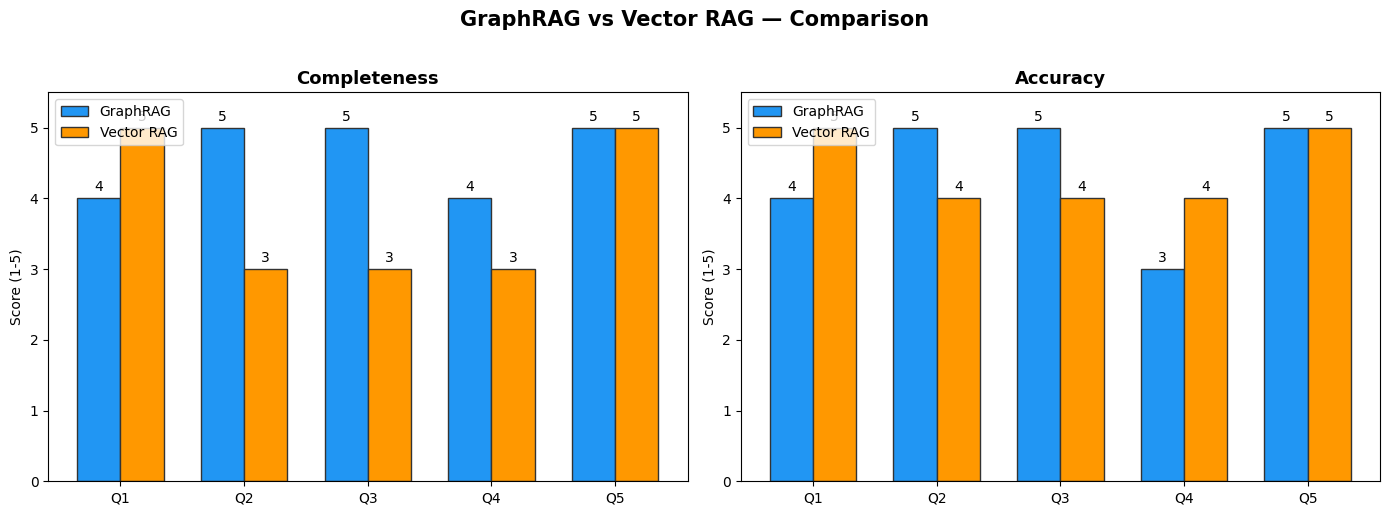


Average scores:
  GraphRAG:  completeness=4.6, accuracy=4.4
  VectorRAG: completeness=3.8, accuracy=4.4


In [53]:
# --- Comparison visualization ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(comparison_questions))
width = 0.35

# Completeness
g_comp = [s["completeness"] for s in graph_scores]
v_comp = [s["completeness"] for s in vector_scores]
axes[0].bar(x - width/2, g_comp, width, label="GraphRAG", color="#2196F3", edgecolor="#333")
axes[0].bar(x + width/2, v_comp, width, label="Vector RAG", color="#FF9800", edgecolor="#333")
axes[0].set_title("Completeness", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Score (1-5)")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"Q{i+1}" for i in range(len(comparison_questions))])
axes[0].set_ylim(0, 5.5)
axes[0].legend()
for i in range(len(x)):
    axes[0].text(x[i] - width/2, g_comp[i] + 0.1, str(g_comp[i]), ha="center", fontsize=10)
    axes[0].text(x[i] + width/2, v_comp[i] + 0.1, str(v_comp[i]), ha="center", fontsize=10)

# Accuracy
g_acc = [s["accuracy"] for s in graph_scores]
v_acc = [s["accuracy"] for s in vector_scores]
axes[1].bar(x - width/2, g_acc, width, label="GraphRAG", color="#2196F3", edgecolor="#333")
axes[1].bar(x + width/2, v_acc, width, label="Vector RAG", color="#FF9800", edgecolor="#333")
axes[1].set_title("Accuracy", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Score (1-5)")
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"Q{i+1}" for i in range(len(comparison_questions))])
axes[1].set_ylim(0, 5.5)
axes[1].legend()
for i in range(len(x)):
    axes[1].text(x[i] - width/2, g_acc[i] + 0.1, str(g_acc[i]), ha="center", fontsize=10)
    axes[1].text(x[i] + width/2, v_acc[i] + 0.1, str(v_acc[i]), ha="center", fontsize=10)

plt.suptitle("GraphRAG vs Vector RAG — Comparison",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nAverage scores:")
print(f"  GraphRAG:  completeness={np.mean(g_comp):.1f}, accuracy={np.mean(g_acc):.1f}")
print(f"  VectorRAG: completeness={np.mean(v_comp):.1f}, accuracy={np.mean(v_acc):.1f}")

---
## 7. Comparison Table: Vector RAG vs GraphRAG

In [54]:
# Build comparison table
rows = []
for i, comp in enumerate(comparison_results):
    rows.append({
        "#": i + 1,
        "Question": comp["question"][:60] + "...",
        "GraphRAG (completeness)": graph_scores[i]["completeness"],
        "GraphRAG (accuracy)": graph_scores[i]["accuracy"],
        "VectorRAG (completeness)": vector_scores[i]["completeness"],
        "VectorRAG (accuracy)": vector_scores[i]["accuracy"],
    })

df = pd.DataFrame(rows)
display(df)

# Summary
print(f"\nAverage scores:")
print(f"  GraphRAG:  completeness={df['GraphRAG (completeness)'].mean():.2f}, accuracy={df['GraphRAG (accuracy)'].mean():.2f}")
print(f"  VectorRAG: completeness={df['VectorRAG (completeness)'].mean():.2f}, accuracy={df['VectorRAG (accuracy)'].mean():.2f}")

,#,Question,GraphRAG (completeness),GraphRAG (accuracy),VectorRAG (completeness),VectorRAG (accuracy)
0,1,Какие инфраструктурные проекты связаны с напра...,4,4,5,5
1,2,Какие компании упоминаются в обоих отчётах?...,5,5,3,4
2,3,Покажите связь между ESG-рейтингом КТЖ и конкр...,5,5,3,4
3,4,Какие дочерние компании есть у Матен Петролеум...,4,3,3,4
4,5,Какие стандарты ISO внедрены в КТЖ?...,5,5,5,5



Average scores:
  GraphRAG:  completeness=4.60, accuracy=4.40
  VectorRAG: completeness=3.80, accuracy=4.40


In [55]:
# --- Text visualization of entity neighborhood ---

def show_entity_neighborhood(entity_name: str):
    """Show all connections of an entity."""
    results = run_cypher("""
        MATCH (center {name: $name})
        OPTIONAL MATCH (center)-[r]->(out)
        WITH center, collect('  --> ' + type(r) + ' --> ' + coalesce(out.name, '?')) AS out_lines
        OPTIONAL MATCH (inp)-[r2]->(center)
        WITH center, out_lines, collect('  <-- ' + type(r2) + ' <-- ' + coalesce(inp.name, '?')) AS in_lines
        RETURN out_lines + in_lines AS lines
    """, {"name": entity_name})

    print(f"\n{entity_name}:")
    if results and results[0]["lines"]:
        for line in results[0]["lines"]:
            print(line)
    else:
        print("  (no connections found)")

# Show neighborhood of key entities (highest degree)
key_entities = run_cypher("""
    MATCH (n)
    WHERE n.name IS NOT NULL
    WITH n, COUNT { (n)-[]-() } AS degree
    ORDER BY degree DESC
    LIMIT 6
    RETURN n.name AS name
""")

print("Key entity neighborhoods:")
print("=" * 60)
for row in key_entities:
    show_entity_neighborhood(row["name"])

Key entity neighborhoods:

АО «НК «ҚТЖ»:
  --> SUBSIDIARY_OF --> Moody's Investors Service
  --> FROM_CHUNK --> ?
  --> FROM_CHUNK --> ?
  --> FROM_CHUNK --> ?
  --> FROM_CHUNK --> ?
  --> FROM_CHUNK --> ?
  --> FROM_CHUNK --> ?
  --> FROM_CHUNK --> ?
  --> FROM_CHUNK --> ?
  --> FROM_CHUNK --> ?
  --> FROM_CHUNK --> ?
  --> FROM_CHUNK --> ?
  --> FROM_CHUNK --> ?
  --> FROM_CHUNK --> ?
  --> FROM_CHUNK --> ?
  --> FROM_CHUNK --> ?
  --> FROM_CHUNK --> ?
  --> IMPLEMENTS --> GRI
  --> IMPLEMENTS --> TCFD
  --> IMPLEMENTS --> SASB
  --> PARTNER_OF --> S&P Global
  --> PARTNER_OF --> PricewaterhouseCoopers (PwC)
  --> PARTNER_OF --> PSA
  --> PARTNER_OF --> Moody’s
  --> PARTNER_OF --> ЗАО «АЖД»
  --> PARTNER_OF --> Maqsut Narikbayev University
  --> PARTNER_OF --> Yuxinou (Chongqing) Logistics Co., Ltd.
  --> PARTNER_OF --> Xian Free Trade Port Construction and Operation Co.,Ltd
  --> PARTNER_OF --> АО «Славтранс-Сервис»
  --> PARTNER_OF --> ГО «Белорусская железная дорога»
  --> PARTNE

In [56]:
# --- Useful Cypher queries for Neo4j Browser ---

useful_queries = {
    "Full graph (for small graphs)": 
        "MATCH (n)-[r]->(m) RETURN n, r, m",

    "All KTZh connections":
        'MATCH (n)-[r]-(connected) WHERE n.name CONTAINS "КТЖ" RETURN n, r, connected',

    "All Maten Petroleum connections":
        'MATCH (n)-[r]-(connected) WHERE n.name CONTAINS "Матен" RETURN n, r, connected',

    "Multi-hop: Organization -> Project -> Location":
        "MATCH path = (org:Organization)-[:DEVELOPS]->(proj:Project)-[:LOCATED_IN]->(loc:Location) RETURN path",

    "Shortest path between KTZh and Maten":
        'MATCH path = shortestPath((a)-[*]-(b)) WHERE a.name CONTAINS "КТЖ" AND b.name CONTAINS "Матен" RETURN path',
}

print("Useful Cypher queries for Neo4j Browser (http://localhost:7474):")
print("=" * 70)
for name, query in useful_queries.items():
    print(f"\n{name}:")
    print(f"   {query}")

Useful Cypher queries for Neo4j Browser (http://localhost:7474):

Full graph (for small graphs):
   MATCH (n)-[r]->(m) RETURN n, r, m

All KTZh connections:
   MATCH (n)-[r]-(connected) WHERE n.name CONTAINS "КТЖ" RETURN n, r, connected

All Maten Petroleum connections:
   MATCH (n)-[r]-(connected) WHERE n.name CONTAINS "Матен" RETURN n, r, connected

Multi-hop: Organization -> Project -> Location:
   MATCH path = (org:Organization)-[:DEVELOPS]->(proj:Project)-[:LOCATED_IN]->(loc:Location) RETURN path

Shortest path between KTZh and Maten:
   MATCH path = shortestPath((a)-[*]-(b)) WHERE a.name CONTAINS "КТЖ" AND b.name CONTAINS "Матен" RETURN path


---
## 8. Final Summary

In [57]:
# --- Final summary ---

node_count = run_cypher("MATCH (n) RETURN count(n) AS count")[0]["count"]
rel_count = run_cypher("MATCH ()-[r]->() RETURN count(r) AS count")[0]["count"]

print("=" * 68)
print(" GraphRAG Pipeline — Summary")
print("=" * 68)
print()
print(" Knowledge Graph:")
print(f"   Nodes: {node_count}")
print(f"   Relationships: {rel_count}")
print()
print(" Comparison results:")
print(f"   GraphRAG  — completeness: {np.mean(g_comp):.1f}/5, accuracy: {np.mean(g_acc):.1f}/5")
print(f"   VectorRAG — completeness: {np.mean(v_comp):.1f}/5, accuracy: {np.mean(v_acc):.1f}/5")
print()
print(" Stack:")
print("   LLM:        GPT-4o-mini (extraction + generation)")
print("   Embeddings: text-embedding-3-small (Neo4j), E5-large (Vector RAG)")
print("   Graph DB:   Neo4j 5.x (Docker)")
print("   Library:    neo4j-graphrag-python (SimpleKGPipeline)")
print("=" * 68)

 GraphRAG Pipeline — Summary

 Knowledge Graph:
   Nodes: 394
   Relationships: 564

 Comparison results:
   GraphRAG  — completeness: 4.6/5, accuracy: 4.4/5
   VectorRAG — completeness: 3.8/5, accuracy: 4.4/5

 Stack:
   LLM:        GPT-4o-mini (extraction + generation)
   Embeddings: text-embedding-3-small (Neo4j), E5-large (Vector RAG)
   Graph DB:   Neo4j 5.x (Docker)
   Library:    neo4j-graphrag-python (SimpleKGPipeline)


In [58]:
# --- Close connection ---
driver.close()
print("Neo4j connection closed.")

Neo4j connection closed.


---
## Conclusions

### What was done

1. **Built a Knowledge Graph** from KTZh and Maten Petroleum annual reports
   - LLM (GPT-4o-mini) extracted entities: organizations, people, projects, locations, standards
   - Identified relationships: subsidiaries, locations, standards, projects
   - Entity Resolution merged duplicates

2. **Implemented GraphRAG pipeline** with VectorCypherRetriever
   - Vector search over node embeddings
   - Graph traversal for relationship exploration (1-2 hops)

3. **Compared GraphRAG vs Vector RAG** on the same questions
   - LLM-as-a-Judge evaluation by completeness and accuracy

### When GraphRAG is better

| Scenario | Vector RAG | GraphRAG |
|----------|-----------|----------|
| Simple fact lookup (number, date) | Good | Good |
| Multi-hop: "Who is connected to whom?" | Weak | Strong |
| Relationships between companies | Weak | Strong |
| Aggregation: "What's common in both reports?" | Weak | Strong |
| Exact numbers from tables | Good | Medium |

### When GraphRAG is worse

- **More expensive**: each text fragment is processed by LLM for entity extraction
- **Loss of detail**: graph stores entities and relationships but may lose text nuances
- **Simple document Q&A**: Vector RAG is sufficient and faster